# Testing Fujifilm prescale calibration

In [2]:
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt

Crop our image to the sample size

(7015, 4960, 3)
uint8
(1050, 1200, 3)


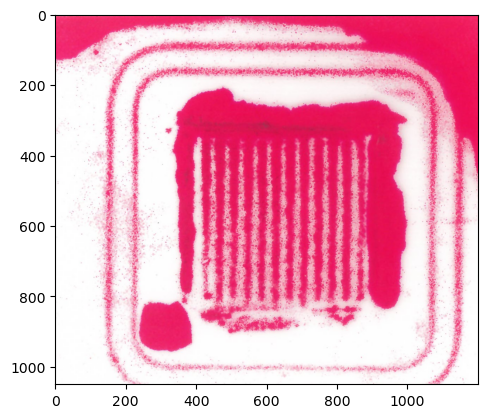

In [3]:
llw_tif = tiff.imread('llw.tif')

print(llw_tif.shape)  # Check actual dimensions first
print(llw_tif.dtype)

# Replace these with values within your actual shape
llw_tif_c = llw_tif[5900:6950, 3500:4700]

print(llw_tif_c.shape)  # Make sure it's non-empty

plt.imshow(llw_tif_c)
plt.show()  # Drop colorbar for RGB images

## 1.0 Colour channels

Extract the colour channels here (R,G,B). The staining is magenta, so green should be very low in the staining (red and blue dominate). Green also has the widest dynamic range, so pick it for further analysis.

In [ ]:
def read_colour_channels(img):
    red = img[:, :, 0].astype(float)
    green = img[:, :, 1].astype(float)
    blue = img[:, :, 2].astype(float)
    return red, green, blue

def compute_optical_density(channel, g0):
    return -np.log10(channel / g0)



red, green, blue = read_colour_channels(llw_tif_c)

# Correct dynamic range
print(f'Red:   min={red.min():.0f}, max={red.max():.0f}, range={red.max()-red.min():.0f}')
print(f'Green: min={green.min():.0f}, max={green.max():.0f}, range={green.max()-green.min():.0f}')
print(f'Blue:  min={blue.min():.0f}, max={blue.max():.0f}, range={blue.max()-blue.min():.0f}')

Red:   min=119, max=255, range=136
Green: min=7, max=255, range=248
Blue:  min=70, max=255, range=185


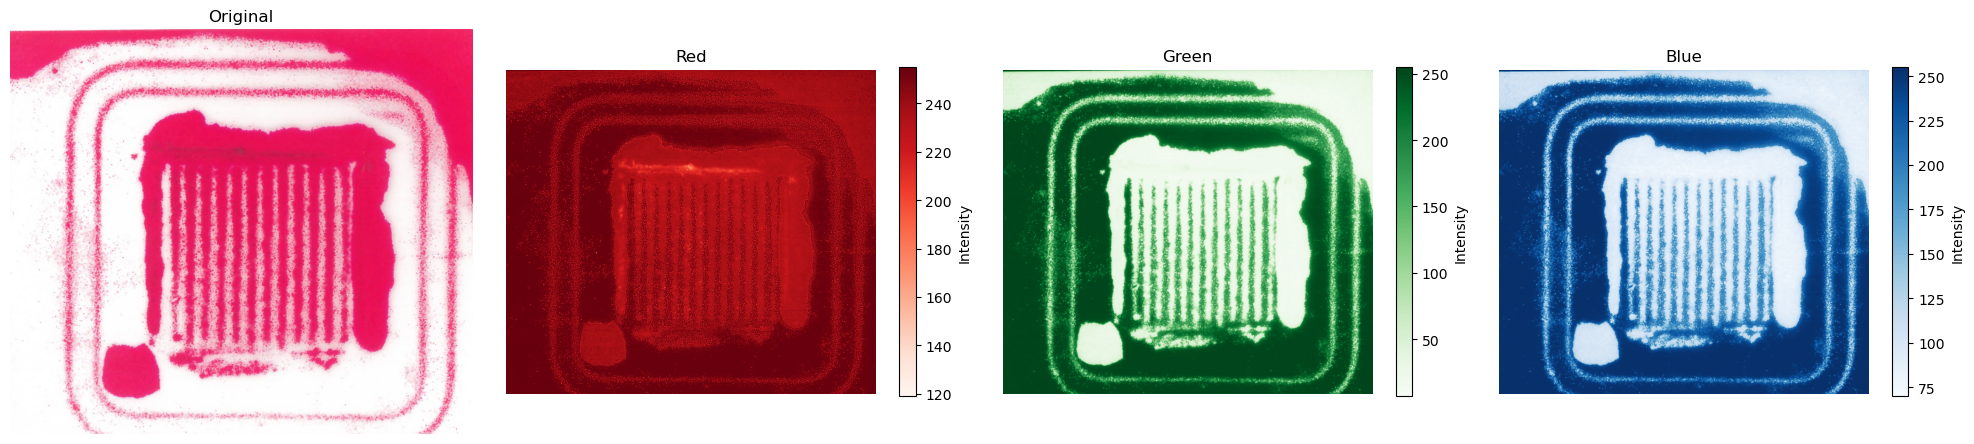

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im0 = axes[0].imshow(llw_tif_c)
axes[0].set_title('Original')

im1 = axes[1].imshow(red, cmap='Reds')
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='Intensity')
axes[1].set_title('Red')

im2 = axes[2].imshow(green, cmap='Greens')
fig.colorbar(im2, ax=axes[2], shrink=0.7, label='Intensity')
axes[2].set_title('Green')

im3 = axes[3].imshow(blue, cmap='Blues')
fig.colorbar(im3, ax=axes[3], shrink=0.7, label='Intensity')
axes[3].set_title('Blue')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()




Seems like the green channel has the widest dynamic range, which is good for calibration. The red and blue channels are more compressed, which may make them less useful for precise measurements.

## 2.0 Calculate the optical density

**Optical density**

$OD = log_{10}(G_0 / G_t)$

Where $G_0$ is the incident light on a white region of the sample and $G_t$ is the transitted green channel intensity.

**Why optical density?**

1. Raw intensity depends on the scanner hardware and calibration. Optical density divides by a white reference ($G_0$) so the scanner's characteristics cancel out, providing reporducable results.

2. Linearity with dye concentration. Light absorption is logarithmic, so each layer of dye absorbs a set fraction of the remaining light. Taking the log means that the dye concentration scales linearly with the optical density.

Here, I used a Konica Minolta scanner in Mansergh on the full color range setting and 600 DPI for the highest resolution.

Take a crop of the green channel so that we can calibrate again a blank area of the film. This will be use to calibrate for the scanner properties.

(<matplotlib.image.AxesImage at 0x28a4d8d6490>,
 <matplotlib.colorbar.Colorbar at 0x28a4d9056d0>)

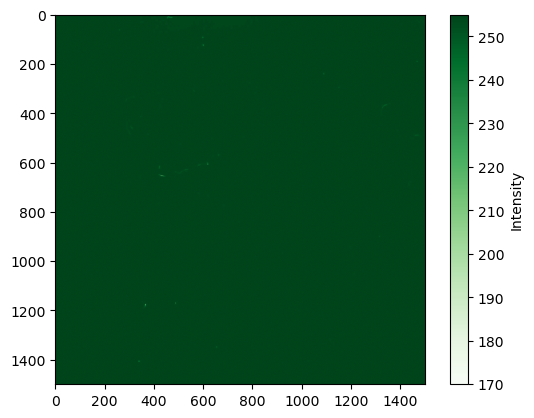

In [28]:
base_swatch = llw_tif[500:2000,:1500, 1]  # Green channel crop for calibration
plt.imshow(base_swatch, cmap='Greens'), plt.colorbar(label='Intensity')

Calibrate again the white reference to compute the optical density. Looks quite good, very close to 255 as expected for a blank area of the film.

In [29]:
# Take a crop of the green channel to compute the white reference
g0 = base_swatch.mean()
print(f'White reference G0: {g0}')

green = np.clip(green, 1, None) # Avoid log(0) by clipping to a minimum of 1
od = -np.log10(green / g0)

White reference G0: 254.9852351111111


## 3.0 Example calibration data

This is just a random calibration curve that I made to test the code. The actual calibration curve will need to be generated from a set of known pressures and their corresponding optical densities. 

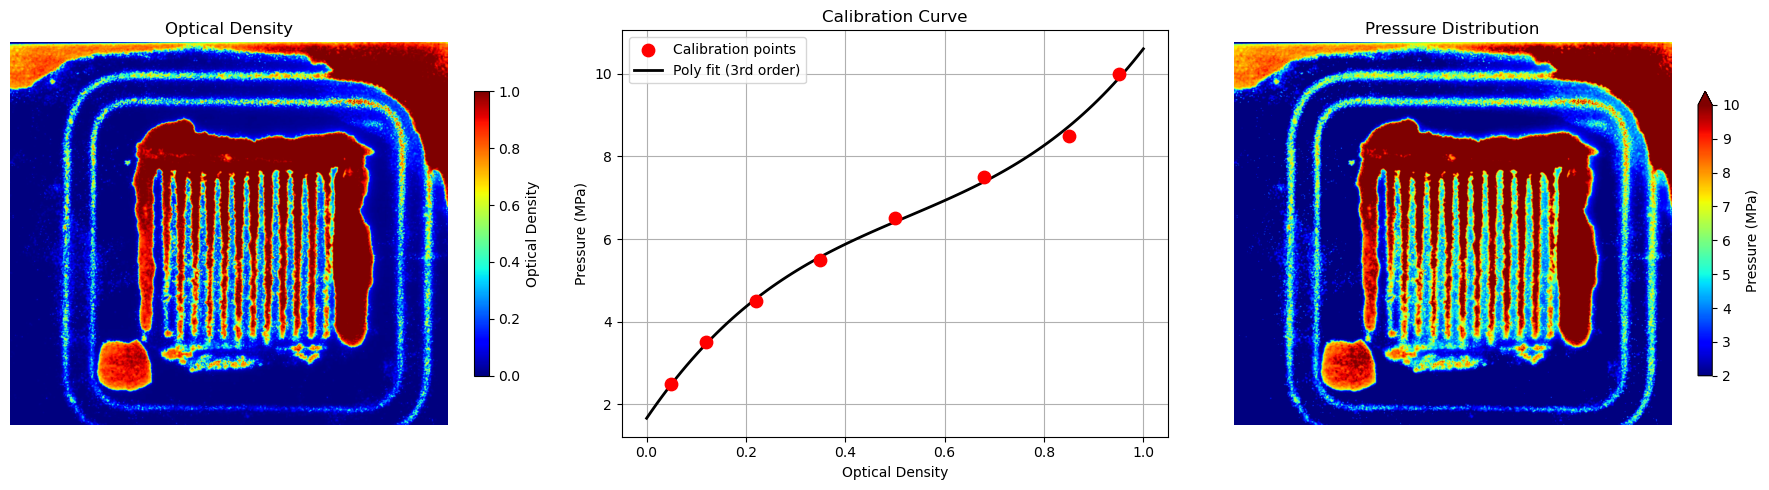

In [31]:
# Calibration data
od_cal = np.array([0.05, 0.12, 0.22, 0.35, 0.50, 0.68, 0.85, 0.95])
p_cal = np.array([2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 10.0])

coeffs = np.polyfit(od_cal, p_cal, 3)
poly = np.poly1d(coeffs)

# Apply calibration
pressure_map = poly(od)
pressure_map = np.clip(pressure_map, 0, 10) # Clip values out of calibration range

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# View optical density
im0 = axes[0].imshow(od, cmap='jet', vmax=1.0)
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='Optical Density')
axes[0].set_title('Optical Density')
axes[0].axis('off')

# View calibration curve
od_fit = np.linspace(0, 1.0, 100)
axes[1].scatter(od_cal, p_cal, color='red', s=80, zorder=5, label='Calibration points')
axes[1].plot(od_fit, poly(od_fit), 'k-', linewidth=2, label='Poly fit (3rd order)')
axes[1].set_xlabel('Optical Density')
axes[1].set_ylabel('Pressure (MPa)')
axes[1].set_title('Calibration Curve')
axes[1].legend()
axes[1].grid(True)

# View pressure map
im2 = axes[2].imshow(pressure_map, cmap='jet', vmin=2, vmax=10)
fig.colorbar(im2, ax=axes[2], shrink=0.7, label='Pressure (MPa)', extend='max')
axes[2].set_title('Pressure Distribution')
axes[2].axis('off')

plt.tight_layout()
plt.show()